# Discrete Decisions and Differentiable Relaxations

Many engineering problems involve discrete decisions (on/off, which equipment to use, integer quantities). These are inherently non-differentiable, but we can use **relaxations** to enable gradient-based optimization.

**Topics covered:**
1. The challenge of discrete variables
2. Continuous relaxations
3. Gumbel-Softmax for differentiable sampling
4. Straight-through estimators
5. Soft switching for discontinuities
6. Chemical engineering application: Equipment selection

In [1]:
import jax
import jax.numpy as jnp
from jax import random, grad, jit, vmap
from jax import lax
from jax import custom_vjp
import jax.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from functools import partial
import optax

jax.config.update("jax_enable_x64", True)

print(f"JAX version: {jax.__version__}")

JAX version: 0.8.1


## 1. The Challenge of Discrete Variables

Consider choosing between $n$ options (equipment types, reaction pathways, etc.):

$$z \in \{0, 1\}^n, \quad \sum_i z_i = 1$$

This is a **one-hot** encoding. The gradient of $z$ with respect to any continuous parameter is **zero** almost everywhere (and undefined at switching points).

**Problem:** Gradient descent can't optimize discrete choices!

In [2]:
# Example: Choosing between 3 reactor types

def reactor_cost_discrete(choice_logits):
    """
    Total cost based on discrete reactor choice.
    
    choice_logits: (3,) array of preference scores
    Returns: cost of the chosen reactor
    """
    # Hard choice: pick the highest logit
    choice = jnp.argmax(choice_logits)
    
    # Reactor costs
    costs = jnp.array([100.0, 150.0, 80.0])  # CSTR, PFR, Batch
    
    return costs[choice]

# Try to compute gradient
logits = jnp.array([1.0, 0.5, 0.8])

print(f"Logits: {logits}")
print(f"Choice: reactor {jnp.argmax(logits)} (CSTR)")
print(f"Cost: ${reactor_cost_discrete(logits)}")

# Gradient is zero!
try:
    gradient = grad(reactor_cost_discrete)(logits)
    print(f"Gradient: {gradient}")
except Exception as e:
    print(f"Error: {e}")

print("\nNote: Gradient is zero because argmax is piecewise constant!")

Metal device set to: Apple M4 Pro
Logits: [1.  0.5 0.8]
Choice: reactor 0 (CSTR)
Cost: $100.0
Gradient: [0. 0. 0.]

Note: Gradient is zero because argmax is piecewise constant!


W0000 00:00:1767134392.173788 4112371 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1767134392.183118 4112371 service.cc:145] XLA service 0x600002de4700 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767134392.183127 4112371 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1767134392.184155 4112371 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1767134392.184162 4112371 mps_client.cc:384] XLA backend will use up to 51539132416 bytes on device 0 for SimpleAllocator.


## 2. Continuous Relaxations

**Idea:** Replace the discrete choice with a continuous approximation.

Instead of one-hot vector $z \in \{0,1\}^n$, use softmax:

$$\pi_i = \frac{\exp(\theta_i / \tau)}{\sum_j \exp(\theta_j / \tau)}$$

Where $\tau$ is a **temperature** parameter:
- $\tau \to 0$: Approaches hard one-hot
- $\tau \to \infty$: Uniform distribution

In [3]:
def reactor_cost_relaxed(choice_logits, temperature=1.0):
    """
    Cost with soft (relaxed) reactor choice.
    
    Instead of picking one, we take weighted average.
    """
    # Soft choice using softmax
    weights = nn.softmax(choice_logits / temperature)
    
    # Reactor costs
    costs = jnp.array([100.0, 150.0, 80.0])
    
    # Expected cost
    return jnp.sum(weights * costs)

# Now gradient exists!
logits = jnp.array([1.0, 0.5, 0.8])

print("Relaxed (soft) reactor choice:")
for tau in [10.0, 1.0, 0.1, 0.01]:
    weights = nn.softmax(logits / tau)
    cost = reactor_cost_relaxed(logits, tau)
    grads = grad(lambda x: reactor_cost_relaxed(x, tau))(logits)
    
    print(f"\n  τ = {tau}:")
    print(f"    Weights: [{weights[0]:.3f}, {weights[1]:.3f}, {weights[2]:.3f}]")
    print(f"    Cost: ${cost:.2f}")
    print(f"    Gradient: [{grads[0]:.3f}, {grads[1]:.3f}, {grads[2]:.3f}]")

Relaxed (soft) reactor choice:



  τ = 10.0:
    Weights: [0.341, 0.324, 0.334]
    Cost: $109.54
    Gradient: [-0.325, 1.313, -0.988]

  τ = 1.0:
    Weights: [0.412, 0.250, 0.338]
    Cost: $105.75
    Gradient: [-2.372, 11.066, -8.694]

  τ = 0.1:
    Weights: [0.876, 0.006, 0.118]
    Cost: $97.92
    Gradient: [18.169, 3.072, -21.241]

  τ = 0.01:
    Weights: [1.000, 0.000, 0.000]
    Cost: $100.00
    Gradient: [0.000, 0.000, -0.000]


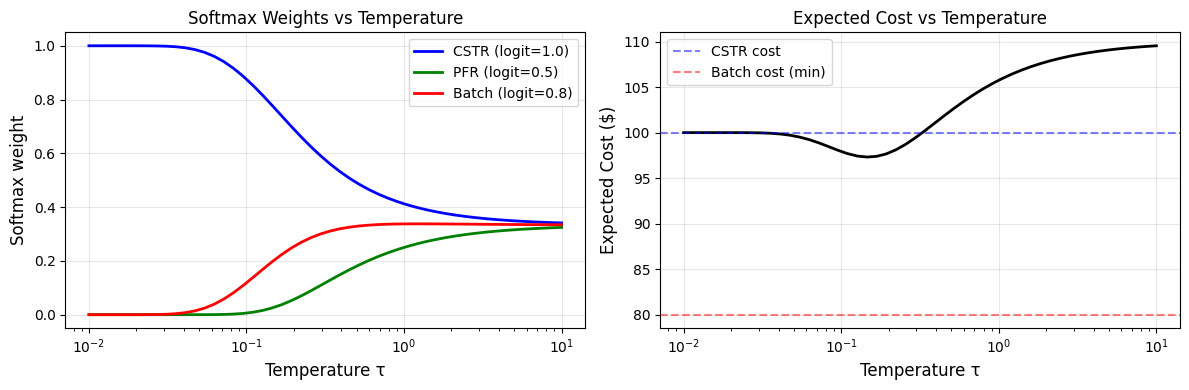


As τ→0: Hard selection of highest logit (CSTR, cost=$100)
The true minimum cost ($80 for Batch) requires optimizing the logits!


In [4]:
# Visualize softmax temperature effect

logits = jnp.array([1.0, 0.5, 0.8])
temperatures = jnp.logspace(-2, 1, 50)

weights_history = []
for tau in temperatures:
    weights_history.append(nn.softmax(logits / tau))

weights_history = jnp.array(weights_history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Weight evolution
axes[0].semilogx(temperatures, weights_history[:, 0], 'b-', label='CSTR (logit=1.0)', linewidth=2)
axes[0].semilogx(temperatures, weights_history[:, 1], 'g-', label='PFR (logit=0.5)', linewidth=2)
axes[0].semilogx(temperatures, weights_history[:, 2], 'r-', label='Batch (logit=0.8)', linewidth=2)
axes[0].set_xlabel('Temperature τ', fontsize=12)
axes[0].set_ylabel('Softmax weight', fontsize=12)
axes[0].set_title('Softmax Weights vs Temperature', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Expected cost
costs = jnp.array([100.0, 150.0, 80.0])
expected_costs = weights_history @ costs

axes[1].semilogx(temperatures, expected_costs, 'k-', linewidth=2)
axes[1].axhline(100, color='b', linestyle='--', alpha=0.5, label='CSTR cost')
axes[1].axhline(80, color='r', linestyle='--', alpha=0.5, label='Batch cost (min)')
axes[1].set_xlabel('Temperature τ', fontsize=12)
axes[1].set_ylabel('Expected Cost ($)', fontsize=12)
axes[1].set_title('Expected Cost vs Temperature', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nAs τ→0: Hard selection of highest logit (CSTR, cost=$100)")
print("The true minimum cost ($80 for Batch) requires optimizing the logits!")

## 3. Gumbel-Softmax Trick

For **sampling** discrete choices in a differentiable way, use the Gumbel-Softmax (or Concrete) distribution:

$$y_i = \frac{\exp((\log \pi_i + g_i) / \tau)}{\sum_j \exp((\log \pi_j + g_j) / \tau)}$$

Where $g_i \sim \text{Gumbel}(0, 1)$ are independent Gumbel noise samples.

**Key insight:** As $\tau \to 0$, this samples from the categorical distribution $\text{Cat}(\pi)$, but gradients flow through!

In [5]:
def sample_gumbel(key, shape):
    """Sample from Gumbel(0, 1) distribution."""
    U = random.uniform(key, shape, minval=1e-10, maxval=1.0)
    return -jnp.log(-jnp.log(U))

def gumbel_softmax(key, logits, temperature=1.0):
    """
    Sample from Gumbel-Softmax distribution.
    
    Returns soft sample that approximates one-hot as τ→0.
    """
    gumbel_noise = sample_gumbel(key, logits.shape)
    return nn.softmax((logits + gumbel_noise) / temperature)

def gumbel_softmax_hard(key, logits, temperature=1.0):
    """
    Gumbel-Softmax with straight-through for hard samples.
    
    Forward: returns hard one-hot
    Backward: gradients flow through soft sample
    """
    soft = gumbel_softmax(key, logits, temperature)
    hard = nn.one_hot(jnp.argmax(soft), len(logits))
    # Straight-through: use hard in forward, soft gradients in backward
    return hard - lax.stop_gradient(soft) + soft

# Demonstrate
key = random.PRNGKey(42)
logits = jnp.array([1.0, 0.5, 0.8])

print("Gumbel-Softmax samples at different temperatures:")
for tau in [1.0, 0.5, 0.1]:
    samples = []
    for i in range(5):
        key, subkey = random.split(key)
        sample = gumbel_softmax(subkey, logits, tau)
        samples.append(sample)
    
    print(f"\n  τ = {tau}:")
    for s in samples[:3]:
        print(f"    [{s[0]:.3f}, {s[1]:.3f}, {s[2]:.3f}]")

Gumbel-Softmax samples at different temperatures:

  τ = 1.0:
    [0.721, 0.216, 0.063]
    [0.072, 0.032, 0.896]
    [0.780, 0.132, 0.088]

  τ = 0.5:
    [0.189, 0.750, 0.061]
    [0.119, 0.066, 0.815]
    [0.975, 0.000, 0.025]

  τ = 0.1:
    [1.000, 0.000, 0.000]
    [0.000, 1.000, 0.000]
    [0.454, 0.546, 0.000]


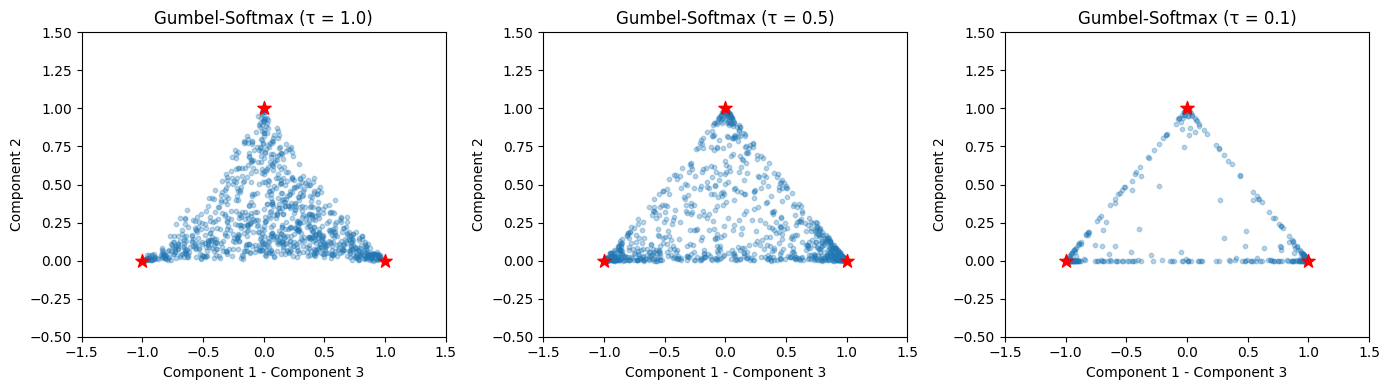

As τ decreases, samples concentrate at one-hot corners.
Red stars = pure one-hot vectors (corners of probability simplex)


In [6]:
# Visualize Gumbel-Softmax distribution

key = random.PRNGKey(0)
logits = jnp.array([1.0, 0.5, 0.8])
n_samples = 1000

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for idx, tau in enumerate([1.0, 0.5, 0.1]):
    samples = []
    for i in range(n_samples):
        key, subkey = random.split(key)
        sample = gumbel_softmax(subkey, logits, tau)
        samples.append(sample)
    
    samples = jnp.array(samples)
    
    # Scatter plot in 2D (simplex projection)
    x = samples[:, 0] - samples[:, 2]
    y = samples[:, 1]
    
    axes[idx].scatter(x, y, alpha=0.3, s=10)
    axes[idx].set_xlabel('Component 1 - Component 3')
    axes[idx].set_ylabel('Component 2')
    axes[idx].set_title(f'Gumbel-Softmax (τ = {tau})')
    axes[idx].set_xlim(-1.5, 1.5)
    axes[idx].set_ylim(-0.5, 1.5)
    
    # Mark corners (one-hot positions)
    corners = jnp.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
    cx = corners[:, 0] - corners[:, 2]
    cy = corners[:, 1]
    axes[idx].scatter(cx, cy, c='red', s=100, marker='*', zorder=5)

plt.tight_layout()
plt.show()

print("As τ decreases, samples concentrate at one-hot corners.")
print("Red stars = pure one-hot vectors (corners of probability simplex)")

In [7]:
# Gradient through Gumbel-Softmax

def expected_cost_gumbel(logits, key, temperature=0.5):
    """Expected cost using Gumbel-Softmax sample."""
    sample = gumbel_softmax(key, logits, temperature)
    costs = jnp.array([100.0, 150.0, 80.0])
    return jnp.sum(sample * costs)

# Gradient with Gumbel-Softmax
key = random.PRNGKey(42)
logits = jnp.array([1.0, 0.5, 0.8])

# Average gradient over multiple samples
grads = []
for i in range(100):
    key, subkey = random.split(key)
    g = grad(lambda x: expected_cost_gumbel(x, subkey))(logits)
    grads.append(g)

mean_grad = jnp.mean(jnp.array(grads), axis=0)
std_grad = jnp.std(jnp.array(grads), axis=0)

print("Gradient through Gumbel-Softmax (averaged over 100 samples):")
print(f"  Mean gradient: [{mean_grad[0]:.3f}, {mean_grad[1]:.3f}, {mean_grad[2]:.3f}]")
print(f"  Std gradient:  [{std_grad[0]:.3f}, {std_grad[1]:.3f}, {std_grad[2]:.3f}]")
print("\nNegative gradient for Batch (index 2) means: increase its logit to reduce cost!")

Gradient through Gumbel-Softmax (averaged over 100 samples):
  Mean gradient: [-2.818, 10.399, -7.580]
  Std gradient:  [7.479, 9.890, 7.728]

Negative gradient for Batch (index 2) means: increase its logit to reduce cost!


## 4. Straight-Through Estimators

For when you need **hard** discrete outputs but still want gradients:

- **Forward pass:** Use hard (argmax) output
- **Backward pass:** Use soft gradient (as if it were softmax)

This is implemented using `lax.stop_gradient`.

In [8]:
def straight_through_argmax(logits, temperature=1.0):
    """
    Straight-through estimator for argmax.
    
    Forward: hard one-hot (argmax)
    Backward: softmax gradient
    """
    soft = nn.softmax(logits / temperature)
    hard = nn.one_hot(jnp.argmax(logits), len(logits))
    
    # Trick: hard - stop_grad(soft) + soft
    # Forward: hard - soft + soft = hard
    # Backward: grad flows through soft only
    return hard - lax.stop_gradient(soft) + soft

def cost_with_straight_through(logits):
    """Cost using straight-through selection."""
    selection = straight_through_argmax(logits, temperature=0.5)
    costs = jnp.array([100.0, 150.0, 80.0])
    return jnp.sum(selection * costs)

logits = jnp.array([1.0, 0.5, 0.8])

# Forward uses hard selection
selection = straight_through_argmax(logits)
cost = cost_with_straight_through(logits)

# But gradient exists!
grads = grad(cost_with_straight_through)(logits)

print("Straight-Through Estimator:")
print(f"  Selection (hard): {selection}")
print(f"  Cost: ${cost:.2f}")
print(f"  Gradient: [{grads[0]:.3f}, {grads[1]:.3f}, {grads[2]:.3f}]")

Straight-Through Estimator:
  Selection (hard): [1. 0. 0.]
  Cost: $100.00
  Gradient: [-2.401, 17.166, -14.765]


## 5. Soft Switching for Discontinuities

Many physical processes have discontinuities:
- Phase transitions (liquid ↔ vapor)
- Valve on/off
- Equipment operating modes

We can approximate these with **sigmoid** (for binary) or **softmax** (for multiple options).

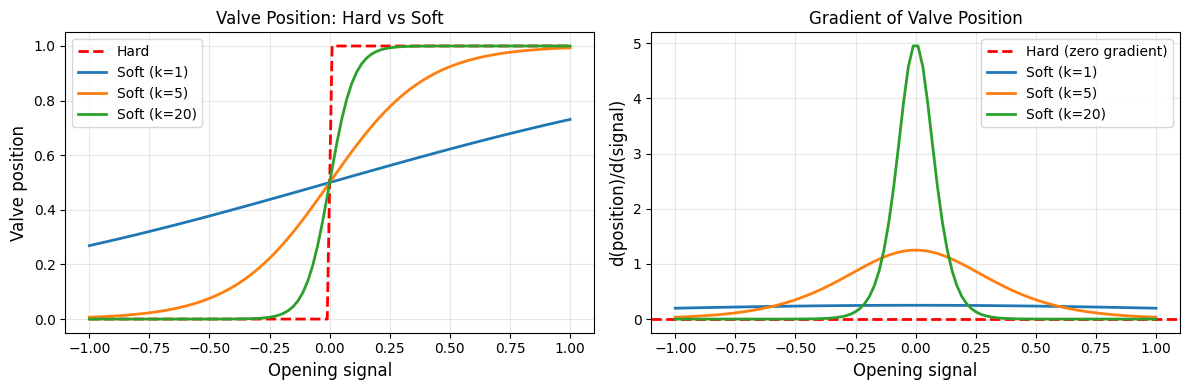

In [9]:
# Example: Valve with smooth on/off transition

def valve_hard(opening_signal):
    """Hard valve: fully open if signal > 0, else closed."""
    return jnp.where(opening_signal > 0, 1.0, 0.0)

def valve_soft(opening_signal, sharpness=10.0):
    """
    Soft valve using sigmoid.
    sharpness controls how sharp the transition is.
    """
    return nn.sigmoid(sharpness * opening_signal)

# Visualize
signals = jnp.linspace(-1, 1, 100)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Valve positions
axes[0].plot(signals, vmap(valve_hard)(signals), 'r--', label='Hard', linewidth=2)
for sharp in [1, 5, 20]:
    axes[0].plot(signals, vmap(lambda s: valve_soft(s, sharp))(signals), 
                 label=f'Soft (k={sharp})', linewidth=2)
axes[0].set_xlabel('Opening signal', fontsize=12)
axes[0].set_ylabel('Valve position', fontsize=12)
axes[0].set_title('Valve Position: Hard vs Soft', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gradients
axes[1].axhline(0, color='r', linestyle='--', label='Hard (zero gradient)', linewidth=2)
for sharp in [1, 5, 20]:
    grad_vals = vmap(grad(lambda s: valve_soft(s, sharp)))(signals)
    axes[1].plot(signals, grad_vals, label=f'Soft (k={sharp})', linewidth=2)
axes[1].set_xlabel('Opening signal', fontsize=12)
axes[1].set_ylabel('d(position)/d(signal)', fontsize=12)
axes[1].set_title('Gradient of Valve Position', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

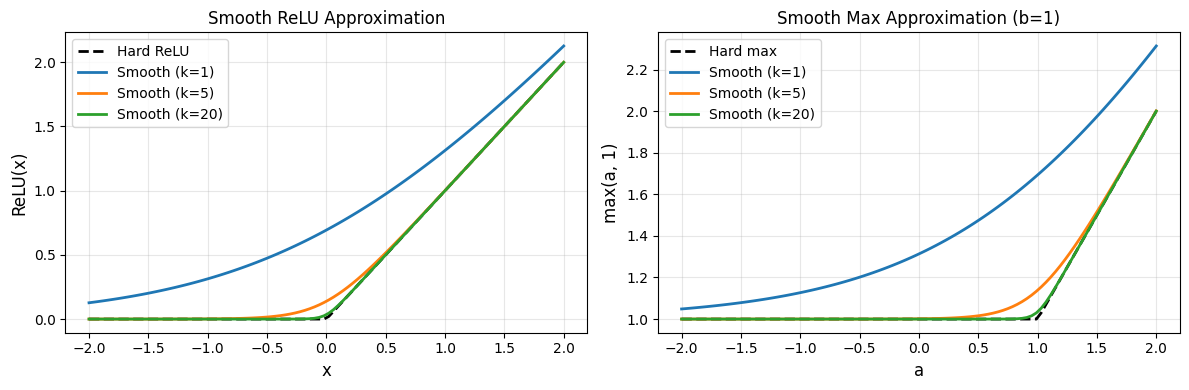

In [10]:
# Example: Smooth min/max approximations

def smooth_max(a, b, sharpness=10.0):
    """Differentiable approximation to max(a, b)."""
    # Using log-sum-exp trick
    return (1/sharpness) * jnp.log(jnp.exp(sharpness * a) + jnp.exp(sharpness * b))

def smooth_min(a, b, sharpness=10.0):
    """Differentiable approximation to min(a, b)."""
    return -smooth_max(-a, -b, sharpness)

def smooth_relu(x, sharpness=10.0):
    """Differentiable approximation to max(0, x)."""
    return smooth_max(jnp.zeros_like(x), x, sharpness)

# Visualize
x = jnp.linspace(-2, 2, 100)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Smooth ReLU
axes[0].plot(x, jnp.maximum(0, x), 'k--', label='Hard ReLU', linewidth=2)
for sharp in [1, 5, 20]:
    axes[0].plot(x, vmap(lambda x: smooth_relu(x, sharp))(x), 
                 label=f'Smooth (k={sharp})', linewidth=2)
axes[0].set_xlabel('x', fontsize=12)
axes[0].set_ylabel('ReLU(x)', fontsize=12)
axes[0].set_title('Smooth ReLU Approximation', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Smooth max(a, b) for a=0
b = 1.0
a_vals = jnp.linspace(-2, 2, 100)
axes[1].plot(a_vals, jnp.maximum(a_vals, b), 'k--', label='Hard max', linewidth=2)
for sharp in [1, 5, 20]:
    axes[1].plot(a_vals, vmap(lambda a: smooth_max(a, b, sharp))(a_vals), 
                 label=f'Smooth (k={sharp})', linewidth=2)
axes[1].set_xlabel('a', fontsize=12)
axes[1].set_ylabel('max(a, 1)', fontsize=12)
axes[1].set_title('Smooth Max Approximation (b=1)', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Chemical Engineering Application: Equipment Selection

**Problem:** Choose between different reactor types to minimize total cost while meeting production requirements.

- 3 reactor options: CSTR, PFR, Batch
- Each has different capital cost, operating cost, and conversion
- Must achieve minimum conversion of 90%

In [11]:
# Equipment data
equipment = {
    'CSTR': {'capital': 100.0, 'operating': 20.0, 'max_conversion': 0.85, 'flexibility': 0.9},
    'PFR': {'capital': 150.0, 'operating': 15.0, 'max_conversion': 0.95, 'flexibility': 0.7},
    'Batch': {'capital': 80.0, 'operating': 30.0, 'max_conversion': 0.98, 'flexibility': 0.95}
}

# Convert to arrays
capital_costs = jnp.array([100.0, 150.0, 80.0])
operating_costs = jnp.array([20.0, 15.0, 30.0])
max_conversions = jnp.array([0.85, 0.95, 0.98])
flexibilities = jnp.array([0.9, 0.7, 0.95])

def total_cost_soft(logits, production_years=10, temperature=1.0, target_conversion=0.90):
    """
    Total cost with soft equipment selection.
    Includes penalty for not meeting conversion target.
    """
    weights = nn.softmax(logits / temperature)
    
    # Weighted costs
    capital = jnp.sum(weights * capital_costs)
    operating = jnp.sum(weights * operating_costs) * production_years
    
    # Weighted conversion capability
    conversion = jnp.sum(weights * max_conversions)
    
    # Penalty for not meeting target (soft constraint)
    conversion_penalty = 1000.0 * smooth_relu(target_conversion - conversion, sharpness=50)
    
    return capital + operating + conversion_penalty

# Optimize equipment selection
key = random.PRNGKey(42)
logits = jnp.array([0.0, 0.0, 0.0])  # Start with equal preference

optimizer = optax.adam(learning_rate=0.5)
opt_state = optimizer.init(logits)

print("Optimizing equipment selection:")
print(f"{'Iter':<8} {'CSTR':<10} {'PFR':<10} {'Batch':<10} {'Cost':<10} {'Conv':<10}")
print("-" * 58)

# Annealing: start warm, gradually cool
for i in range(100):
    temperature = max(0.1, 2.0 * (0.95 ** i))  # Annealing schedule
    
    loss, grads = jax.value_and_grad(lambda x: total_cost_soft(x, temperature=temperature))(logits)
    updates, opt_state = optimizer.update(grads, opt_state)
    logits = optax.apply_updates(logits, updates)
    
    if i % 20 == 0 or i == 99:
        weights = nn.softmax(logits / temperature)
        conv = jnp.sum(weights * max_conversions)
        print(f"{i:<8} {weights[0]:<10.3f} {weights[1]:<10.3f} {weights[2]:<10.3f} {loss:<10.1f} {conv:<10.3f}")

Optimizing equipment selection:
Iter     CSTR       PFR        Batch      Cost       Conv      
----------------------------------------------------------


0        0.384      0.384      0.233      331.3      0.919     
20       0.000      1.000      0.000      301.6      0.950     
40       0.000      1.000      0.000      301.6      0.950     
60       0.000      1.000      0.000      301.6      0.950     


80       0.000      1.000      0.000      301.6      0.950     
99       0.000      1.000      0.000      301.6      0.950     


In [12]:
# Final selection
final_weights = nn.softmax(logits / 0.1)  # Low temperature for near-hard selection
selected = jnp.argmax(final_weights)
names = ['CSTR', 'PFR', 'Batch']

print("\nFinal Equipment Selection:")
print("=" * 40)
print(f"Selected: {names[selected]}")
print(f"Weights: CSTR={final_weights[0]:.3f}, PFR={final_weights[1]:.3f}, Batch={final_weights[2]:.3f}")
print(f"")
print(f"Selected equipment properties:")
print(f"  Capital cost: ${capital_costs[selected]:.0f}")
print(f"  Operating cost: ${operating_costs[selected]:.0f}/year")
print(f"  Max conversion: {max_conversions[selected]*100:.0f}%")
print(f"  10-year total: ${capital_costs[selected] + 10*operating_costs[selected]:.0f}")


Final Equipment Selection:
Selected: PFR
Weights: CSTR=0.000, PFR=1.000, Batch=0.000

Selected equipment properties:
  Capital cost: $150
  Operating cost: $15/year
  Max conversion: 95%
  10-year total: $300


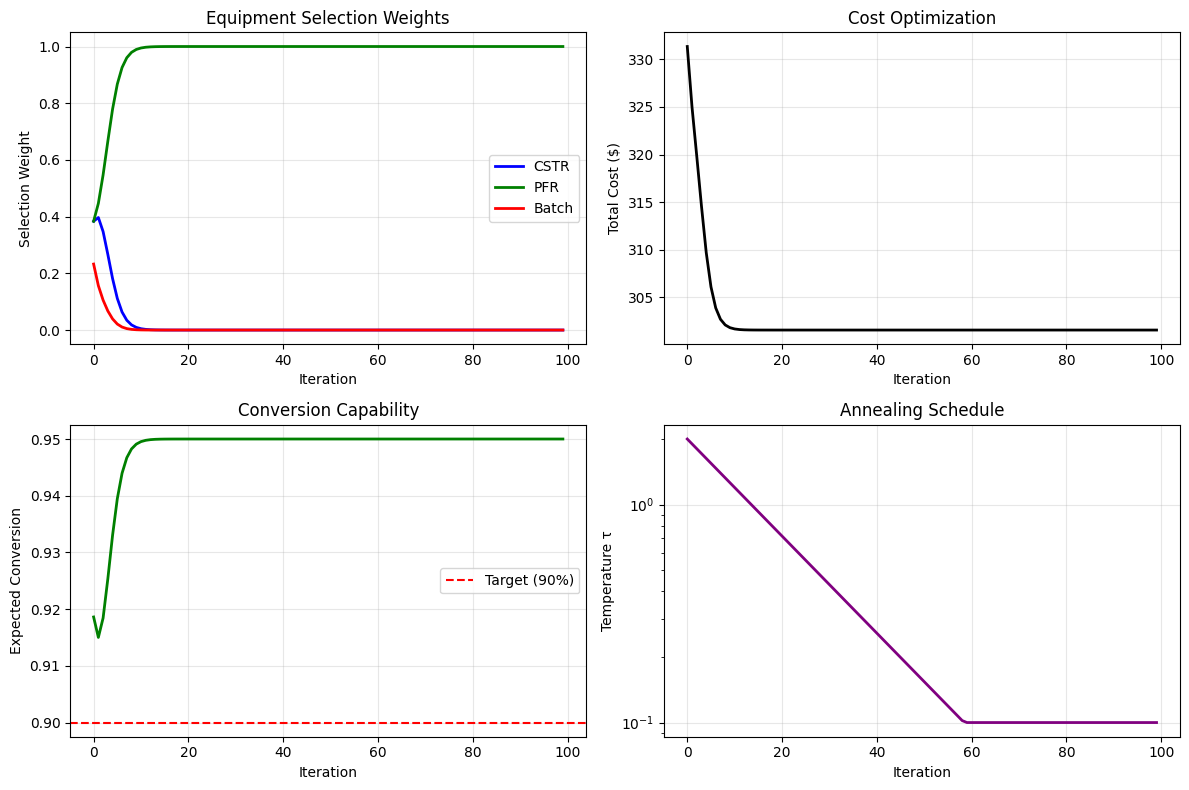

In [13]:
# Visualize optimization trajectory

# Re-run with history tracking
logits = jnp.array([0.0, 0.0, 0.0])
opt_state = optimizer.init(logits)

history = {'weights': [], 'cost': [], 'conversion': [], 'temperature': []}

for i in range(100):
    temperature = max(0.1, 2.0 * (0.95 ** i))
    
    loss, grads = jax.value_and_grad(lambda x: total_cost_soft(x, temperature=temperature))(logits)
    updates, opt_state = optimizer.update(grads, opt_state)
    logits = optax.apply_updates(logits, updates)
    
    weights = nn.softmax(logits / temperature)
    history['weights'].append(weights)
    history['cost'].append(float(loss))
    history['conversion'].append(float(jnp.sum(weights * max_conversions)))
    history['temperature'].append(float(temperature))

# Plot
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Weight evolution
weights_arr = jnp.array(history['weights'])
axes[0, 0].plot(weights_arr[:, 0], 'b-', label='CSTR', linewidth=2)
axes[0, 0].plot(weights_arr[:, 1], 'g-', label='PFR', linewidth=2)
axes[0, 0].plot(weights_arr[:, 2], 'r-', label='Batch', linewidth=2)
axes[0, 0].set_xlabel('Iteration')
axes[0, 0].set_ylabel('Selection Weight')
axes[0, 0].set_title('Equipment Selection Weights')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Cost
axes[0, 1].plot(history['cost'], 'k-', linewidth=2)
axes[0, 1].set_xlabel('Iteration')
axes[0, 1].set_ylabel('Total Cost ($)')
axes[0, 1].set_title('Cost Optimization')
axes[0, 1].grid(True, alpha=0.3)

# Conversion
axes[1, 0].plot(history['conversion'], 'g-', linewidth=2)
axes[1, 0].axhline(0.90, color='r', linestyle='--', label='Target (90%)')
axes[1, 0].set_xlabel('Iteration')
axes[1, 0].set_ylabel('Expected Conversion')
axes[1, 0].set_title('Conversion Capability')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Temperature
axes[1, 1].semilogy(history['temperature'], 'purple', linewidth=2)
axes[1, 1].set_xlabel('Iteration')
axes[1, 1].set_ylabel('Temperature τ')
axes[1, 1].set_title('Annealing Schedule')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Multi-Equipment Flowsheet Selection

Extend to selecting multiple pieces of equipment in a process.

In [14]:
# Multi-unit selection: Reactor + Separator + Heat Exchanger

# Equipment options for each unit type
reactors = {
    'costs': jnp.array([100.0, 150.0, 80.0]),  # CSTR, PFR, Batch
    'performance': jnp.array([0.85, 0.95, 0.98])  # max conversion
}

separators = {
    'costs': jnp.array([50.0, 80.0]),  # Flash, Distillation
    'performance': jnp.array([0.90, 0.99])  # recovery
}

heat_exchangers = {
    'costs': jnp.array([30.0, 60.0, 100.0]),  # Shell-tube, Plate, Spiral
    'performance': jnp.array([0.70, 0.85, 0.95])  # efficiency
}

def flowsheet_cost(params, temperature=1.0):
    """
    Total flowsheet cost with soft equipment selection.
    
    params: dict with 'reactor', 'separator', 'hx' logits
    """
    # Soft selections
    w_reactor = nn.softmax(params['reactor'] / temperature)
    w_separator = nn.softmax(params['separator'] / temperature)
    w_hx = nn.softmax(params['hx'] / temperature)
    
    # Costs
    cost_reactor = jnp.sum(w_reactor * reactors['costs'])
    cost_separator = jnp.sum(w_separator * separators['costs'])
    cost_hx = jnp.sum(w_hx * heat_exchangers['costs'])
    
    total_capital = cost_reactor + cost_separator + cost_hx
    
    # Overall performance (product of individual performances)
    perf_reactor = jnp.sum(w_reactor * reactors['performance'])
    perf_separator = jnp.sum(w_separator * separators['performance'])
    perf_hx = jnp.sum(w_hx * heat_exchangers['performance'])
    
    overall_performance = perf_reactor * perf_separator * perf_hx
    
    # Penalty for low performance (want > 0.75 overall)
    target_performance = 0.75
    performance_penalty = 500.0 * smooth_relu(target_performance - overall_performance, sharpness=50)
    
    return total_capital + performance_penalty

# Initialize
params = {
    'reactor': jnp.array([0.0, 0.0, 0.0]),
    'separator': jnp.array([0.0, 0.0]),
    'hx': jnp.array([0.0, 0.0, 0.0])
}

# Optimize
optimizer = optax.adam(learning_rate=0.3)
opt_state = optimizer.init(params)

print("Optimizing multi-unit flowsheet:")

for i in range(150):
    temperature = max(0.1, 2.0 * (0.97 ** i))
    
    loss, grads = jax.value_and_grad(lambda p: flowsheet_cost(p, temperature=temperature))(params)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)

# Final selections
print("\nOptimal Equipment Selection:")
print("=" * 50)

reactor_names = ['CSTR', 'PFR', 'Batch']
separator_names = ['Flash', 'Distillation']
hx_names = ['Shell-Tube', 'Plate', 'Spiral']

w_r = nn.softmax(params['reactor'] / 0.1)
w_s = nn.softmax(params['separator'] / 0.1)
w_h = nn.softmax(params['hx'] / 0.1)

print(f"\nReactor: {reactor_names[jnp.argmax(w_r)]}")
print(f"  Weights: {dict(zip(reactor_names, [f'{w:.3f}' for w in w_r]))}")
print(f"  Cost: ${reactors['costs'][jnp.argmax(w_r)]:.0f}")

print(f"\nSeparator: {separator_names[jnp.argmax(w_s)]}")
print(f"  Weights: {dict(zip(separator_names, [f'{w:.3f}' for w in w_s]))}")
print(f"  Cost: ${separators['costs'][jnp.argmax(w_s)]:.0f}")

print(f"\nHeat Exchanger: {hx_names[jnp.argmax(w_h)]}")
print(f"  Weights: {dict(zip(hx_names, [f'{w:.3f}' for w in w_h]))}")
print(f"  Cost: ${heat_exchangers['costs'][jnp.argmax(w_h)]:.0f}")

total = (reactors['costs'][jnp.argmax(w_r)] + 
         separators['costs'][jnp.argmax(w_s)] + 
         heat_exchangers['costs'][jnp.argmax(w_h)])
performance = (reactors['performance'][jnp.argmax(w_r)] * 
               separators['performance'][jnp.argmax(w_s)] * 
               heat_exchangers['performance'][jnp.argmax(w_h)])

print(f"\nTotal Capital Cost: ${total:.0f}")
print(f"Overall Performance: {performance*100:.1f}%")

Optimizing multi-unit flowsheet:



Optimal Equipment Selection:

Reactor: Batch
  Weights: {'CSTR': '0.000', 'PFR': '0.000', 'Batch': '1.000'}
  Cost: $80

Separator: Flash
  Weights: {'Flash': '1.000', 'Distillation': '0.000'}
  Cost: $50

Heat Exchanger: Plate
  Weights: {'Shell-Tube': '0.000', 'Plate': '1.000', 'Spiral': '0.000'}
  Cost: $60

Total Capital Cost: $190
Overall Performance: 75.0%


## Summary

**Key techniques for differentiable discrete decisions:**

1. **Continuous relaxation:**
   - Replace one-hot with softmax
   - Temperature controls sharpness
   - Works well for expected value objectives

2. **Gumbel-Softmax:**
   - Differentiable sampling from categorical
   - Useful when you need stochastic exploration
   - Variance reduction through temperature annealing

3. **Straight-through estimator:**
   - Hard output in forward pass
   - Soft gradient in backward pass
   - Best of both worlds (discrete + differentiable)

4. **Soft switching:**
   - Sigmoid for binary decisions
   - Smooth min/max for bounds
   - Handles physical discontinuities

**Chemical engineering applications:**
- Equipment selection (reactor type, separator type)
- Process topology optimization
- Operating mode selection
- Phase transition handling
- Valve and controller logic

**Best practices:**
- Start with high temperature (exploration), anneal to low (exploitation)
- Add soft penalties for constraints
- Verify final solution with hard selection
- Consider multiple random initializations